In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import LabelEncoder
from category_encoders import HashingEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

def divide_sender(list):
    name=[]
    email=[]
    for person in list:
        
        temp=person.split("<")
        if len(temp)==2:
            temp[1]=temp[1][:-1]
        else:
            if temp[0].find("@")==-1:
                temp.append("")
            else:
                temp.insert(0,"")
        name.append(temp[0])
        email.append(temp[1])
    return name,email
def divide_email(list):
    prefix=[]
    domain=[]
    for mail in list:
        temp=mail.split("@")
        if len(temp)!=2:
            prefix.append('')
            domain.append('')
        else:    
            prefix.append(temp[0])
            domain.append([temp[1]])

    return prefix,domain

folder="./email_data/"
CEAS8=pd.read_csv(folder+"CEAS_08.csv")
Enron=pd.read_csv(folder+"Enron.csv")
Ling=pd.read_csv(folder+"Ling.csv")
Nazario=pd.read_csv(folder+"Nazario.csv")
N_fraud=pd.read_csv(folder+"Nigerian_Fraud.csv")
phishing=pd.read_csv(folder+"phishing_email.csv")
spam=pd.read_csv(folder+"SpamAssasin.csv")




url_encoder=LabelEncoder()
label_encoder=LabelEncoder()
body_vectorizer=TfidfVectorizer()
subject_vectorizer=TfidfVectorizer()
name_encoder=HashingEncoder()
email_encoder=HashingEncoder()
domain_encoder=HashingEncoder()

In [2]:
ceas = pd.DataFrame(CEAS8)
nigerian=pd.DataFrame(N_fraud)
nazario = pd.DataFrame(Nazario)
spam_assasin = pd.DataFrame(spam)

ceas=ceas.fillna("")
sendercopy=ceas['sender'].copy()
name_ceas,email_ceas=divide_sender(sendercopy)
prefix_ceas,domain_ceas=divide_email(email_ceas)
subject_ceas = ceas['subject'].copy()
body_ceas = ceas['body'].copy()
urls_ceas = ceas['urls'].copy().astype(int)
label_ceas = ceas['label'].astype(int)

nigerian=nigerian.fillna("")
sendercopy=nigerian['sender'].copy()
name_nigerian,email_nigerian=divide_sender(sendercopy)
prefix_nigerian,domain_nigerian=divide_email(email_nigerian)
subject_nigerian = nigerian['subject'].copy()
body_nigerian = nigerian['body'].copy()
urls_nigerian = nigerian['urls'].copy().astype(int)
label_nigerian = nigerian['label'].astype(int)

nazario=nazario.fillna("")
sendercopy=nazario['sender'].copy()
name_nazario,email_nazario=divide_sender(sendercopy)
prefix_nazario,domain_nazario=divide_email(email_nazario)
subject_nazario = nazario['subject'].copy()
body_nazario = nazario['body'].copy()
urls_nazario = nazario['urls'].copy().astype(int)
label_nazario = nazario['label'].astype(int)

spam_assasin=spam_assasin.fillna("")
sendercopy=spam_assasin['sender'].copy()
name_spam_assasin,email_spam_assasin=divide_sender(sendercopy)
prefix_spam_assasin,domain_spam_assasin=divide_email(email_spam_assasin)
subject_spam_assasin = spam_assasin['subject'].copy()
body_spam_assasin = spam_assasin['body'].copy()
urls_spam_assasin = spam_assasin['urls'].copy().astype(int)
label_spam_assasin = spam_assasin['label'].astype(int)

name_combined = name_ceas + name_nigerian + name_nazario + name_spam_assasin
prefix_combined = prefix_ceas + prefix_nigerian + prefix_nazario + prefix_spam_assasin
domain_combined = domain_ceas + domain_nigerian + domain_nazario + domain_spam_assasin
subject_combined = pd.concat([subject_ceas, subject_nigerian, subject_nazario, subject_spam_assasin], ignore_index=True)
body_combined = pd.concat([body_ceas, body_nigerian, body_nazario, body_spam_assasin], ignore_index=True)
urls_combine = pd.concat([urls_ceas, urls_nigerian, urls_nazario, urls_spam_assasin], ignore_index=True)

(49860, 8)
(49860, 8)
Accuracy:0.9907741676694746
[[4247   66]
 [  26 5633]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4313
           1       0.99      1.00      0.99      5659

    accuracy                           0.99      9972
   macro avg       0.99      0.99      0.99      9972
weighted avg       0.99      0.99      0.99      9972

AUC-ROC: 0.9994877345341452


<function matplotlib.pyplot.show(close=None, block=None)>

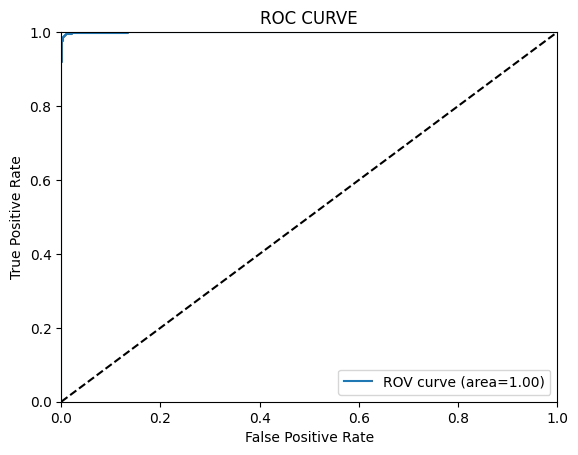

In [3]:
name = name_encoder.fit_transform(name_combined)
prefix = email_encoder.fit_transform(prefix_combined)
domain = domain_encoder.fit_transform(domain_combined)
subject = subject_vectorizer.fit_transform(subject_combined)
body = body_vectorizer.fit_transform(body_combined)
urls = csr_matrix(urls_combine).reshape(-1, 1)

print(name.shape)
print(domain.shape)
X=hstack([name,subject,body,prefix,domain,urls])
y = pd.concat([label_ceas, label_nigerian, label_nazario, label_spam_assasin], ignore_index=True)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
initial_detect=LogisticRegression()
initial_detect.fit(X_train,y_train)

y_pred =initial_detect.predict(X_test)
y_pred_proba = initial_detect.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,y_pred)
conf_matrix= confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(f'Accuracy:{accuracy}')
print(conf_matrix)
print('Classification Report:')
print(class_report)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {roc_auc}")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr,tpr,label=f'ROV curve (area={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend(loc="lower right")
plt.show

In [10]:


def input_email(senderinput,subjectinput,bodyinput,urlsinput,safe,blacklisted):
    detailslist=[]


    spam_threshold=0.6
    for x in range (len(senderinput)):
        print(safe)
        print(blacklisted)
        sender=np.array([senderinput[x]])
        subject=np.array([subjectinput[x]])
        body=np.array([bodyinput[x]])
        urls=np.array([urlsinput[x]])
        safeexit=np.bool(False)
        badexit=np.bool(False)
        details={
            "spam?":0,
            "blmail":False,
            "safemail":False
        }
        name,email=divide_sender(sender)
      
        if email[0] in safe: 
            safeexit=np.bool(True)
            details["safemail"]=True   
            
        if email[0] in blacklisted: 
            badexit=np.bool(True)
            details["blmail"]=True   
        print(safeexit,badexit)
        if(safeexit):
            print("Not Spam")
            print("Reasoning: Whitelisted email",email[0])
        elif(badexit):
            details['spam?']=1
            print("Spam")
            print("Reasoning: Blacklisted email",email[0])
        else:
            prefix,domain=divide_email(email)
            subject=subject_vectorizer.transform(subject)
            body=body_vectorizer.transform(body)
            name=name_encoder.transform(name)
            prefix=email_encoder.transform(prefix)
            domain=domain_encoder.transform(domain)
            urls = np.array(urls, dtype=float).reshape(1, -1)  # shape (1, n_features)
            urls = csr_matrix(urls)
            X=hstack([name,subject,body,prefix,domain,urls])
            spam_prob=initial_detect.predict_proba(X)
            details["spam?"]=spam_prob[0][1]
            if details["spam?"]>=spam_threshold:
                #RUN THE DIFFERENT MODEL TO BE ABLE TO FIND THE VALUES
                print("Likely to be spam")
            else:
                print("Unlikely to be spam.")
                print("Reasoning: Predicted chance of spam was ",(details['spam?']*100),'%')
        detailslist.append(details)
    return detailslist

new_email=np.array([["jeff <helo@ching.com>"],["I need money"],["please"],[2]])
# input_email(new_email[0],new_email[1],new_email[2],new_email[3])

Likely to be spam
Reasoning: Detected spam type was Unknown
['support@microsoft.com', 'rafarukmanto@gmail.com', 'noreply@google.com', 'sprellwiz@wmich.edu']
['noreply@rncrosoft.com', 'helo@ching.com']
False False
Unlikely to be spam.
Reasoning: Predicted chance of spam was  43.856144856511186 %
deets [{'spam?': 0, 'spamtype': 'Unknown', 'blmail': False, 'safemail': True}, {'spam?': np.float64(0.6887111239777454), 'spamtype': 'Unknown', 'blmail': False, 'safemail': False}, {'spam?': 0, 'spamtype': 'Unknown', 'blmail': False, 'safemail': True}, {'spam?': np.float64(0.67593185337464), 'spamtype': 'Unknown', 'blmail': False, 'safemail': False}, {'spam?': np.float64(0.7909594376180558), 'spamtype': 'Unknown', 'blmail': False, 'safemail': False}, {'spam?': np.float64(0.43856144856511187), 'spamtype': 'Unknown', 'blmail': False, 'safemail': False}]
Likely to be spam
Reasoning: Detected spam type was Unknown
['support@microsoft.com', 'rafarukmanto@gmail.com', 'noreply@google.com', 'sprellwiz@w

Exception in thread Thread-194 (_handle_eio_message):
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\rafar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\rafar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\socketio\client.py", line 529, in _handle_eio_message
    self._handle_event(pkt.namespace, pkt.id, pkt.data)
  File "C:\Users\rafar\AppData\Local\Packages\PythonSoftwareFoundatio

['noreply@rncrosoft.com', 'helo@ching.com']
['support@microsoft.com', 'rafarukmanto@gmail.com', 'noreply@google.com', 'sprellwiz@wmich.edu']
recived data {'sender': ['Rafa Rukmanto <rafarukmanto@gmail.com>', 'James Harden <hardenjames@yahoo.com>', 'Microsoft Support <support@microsoft.com>', 'QiMing Official <norepy@qming.com>', 'Chao Yi Cheng <cyc@gmail.com>', 'Stevie Prellwitz <stephanie.prellwitz@wmich.edu>'], 'subject': ['CAR INSURANCE', 'Followup interview details', 'Password Reset', 'Claim free iPhone', 'I left my golf clubs in your attic', '3+1 Modified Course Plan'], 'body': ['extended car insurance nonoononono', 'Hi!, we have reviewed your resume and compiled results from our last interview and decided we would like to move forward in the hiring process. \n We have a timeslot open on Tuesday at 11AM, if you are not available at this time please reach out so we can fins a solution', 'Your password reset code is 58423 please enter it in the browser to change email or go to micro

In [ ]:

import json

import socketio
safe=[]
blacklisted=[]
serverloc="http://localhost:3000"
safeApi="/api/data/safe"
blaclistApi="/api/data/blacklist"
sio = socketio.Client()
sio.connect(serverloc)
# io.emit('Email has been uploaded',email)

@sio.on('safemail')
def changesafemail(data):
        global safe
        safe=data
        print(safe)
@sio.on('blacklisted')
def changeblacklisted(data):
        global blacklisted
        blacklisted=data
        print(blacklisted)
@sio.on("js_to_py")
def process_email(email):
        email=json.loads(email)
        print("recived data",email)
        details=input_email(email['sender'],email['subject'],email['body'],email['urls'],safe,blacklisted)
        print("deets",details)
        sio.emit("py_to_js",details)


# keep the client running
# sio.wait()


['noreply@rncrosoft.com', 'helo@ching.com']


['support@microsoft.com', 'rafarukmanto@gmail.com', 'noreply@google.com', 'sprellwiz@wmich.edu']
recived data {'sender': ['Jeff Epstein <jeff@island.com>', 'Sean Combs <freakybaby@oil.com>', 'Stevie Prellwiz <sprellwiz@wmich.edu>', 'Stevie Prellwiz <sprellwiz@wmich.edu>', 'CARTER PCS <ultraglazer@apple.com>'], 'subject': ['island', 'BOOBS', 'Announcement for graduation registration', 'Announcement for Summer 1 graduation registration', 'IPHONE 17 go BRR'], 'body': ['looking for kids to diddle on my island', 'dont report me or else', 'Application for Spring graduation 2026 has been openen, please go to go.wmich.edu to register by 23 December 2025', 'Application for Summer 1 graduation 2026 has been openen, please go to go.wmich.edu to register by 23 December 2025', 'buy or i lose my paycheck'], 'urls': [0, 0, 1, 1, 0]}
['support@microsoft.com', 'rafarukmanto@gmail.com', 'noreply@google.com', 'sprellwiz@wmich.edu']
['noreply@rncrosoft.com', 'helo@ching.com']
False False
Likely to be spam